#### Daily Clustering — Temporal (All donors, 4 parts of day)

Features = activity share across 4 parts of the day x 5 types (text/audio/react/comm/post) = 20 features

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent.parent))
from config import raw_data, control_data, external_data, raw_kyiv, filtered_data, daily_data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from IPython.display import display

import umap
import hdbscan

import warnings
warnings.filterwarnings('ignore')

In [3]:
war_date = pd.to_datetime('2022-02-24')
pre_start = war_date - pd.DateOffset(months=6)
post_end = war_date + pd.DateOffset(months=6)
random_state = 42

In [4]:
exclude = [
    '06b923ca-4d2d-44bb-8b20-4e2c9b08ce9f',
    '179bbc95-ec8b-4a65-98c5-5d3b566806fa',
]

base = filtered_data

In [5]:
df_t = pd.read_csv(base / 'text_messages_filtered.csv')
df_a = pd.read_csv(base / 'audio_messages_filtered.csv')
df_r = pd.read_csv(base / 'reactions_sorted.csv')
df_c = pd.read_csv(base / 'comments_sorted.csv')
df_p = pd.read_csv(base / 'posts_sorted.csv')

for d in [df_t, df_a, df_r, df_c, df_p]:
    d['datetime'] = pd.to_datetime(d['datetime'])

df_t = df_t[(df_t['is_donor'] == 1) & (~df_t['donation_id'].isin(exclude))]
df_a = df_a[(df_a['is_donor'] == 1) & (~df_a['donation_id'].isin(exclude))]
for d in [df_r, df_c, df_p]:
    d.drop(d[d['donation_id'].isin(exclude)].index, inplace=True)

for d in [df_t, df_a, df_r, df_c, df_p]:
    d['date'] = d['datetime'].dt.date
    d['hour'] = d['datetime'].dt.hour
    d.drop(d[(d['datetime'] < pre_start) | (d['datetime'] >= post_end)].index, inplace=True)

print(f'Donors: {df_t["donation_id"].nunique()}')
print(f'Text: {len(df_t):,}, Audio: {len(df_a):,}')

Donors: 22
Text: 215,312, Audio: 11,575


In [6]:
parts = {
    'morning': range(6,  12),
    'day': range(12, 18),
    'evening': range(18, 23),
    'night': list(range(23, 24)) + list(range(0, 6)),
}

In [7]:
def parts_share_all(df, label):
    if df.empty:
        return pd.DataFrame()
    df = df.copy()
    df['hour'] = pd.to_datetime(df['datetime']).dt.hour
    df['part'] = df['hour'].map(
        lambda h: next((p for p, hrs in parts.items() if h in hrs), 'night')
    )
    counts = (df.groupby(['date', 'part']).size()
               .unstack(fill_value=0)
               .reindex(columns=list(parts.keys()), fill_value=0))
    row_sums = counts.sum(axis=1)
    shares = counts.div(row_sums, axis=0)
    shares.columns = [f'{label}_{p}' for p in parts.keys()]
    return shares

In [8]:
pivots = [
    parts_share_all(df_t, 'text'),
    parts_share_all(df_a, 'audio'),
    parts_share_all(df_r, 'react'),
    parts_share_all(df_c, 'comm'),
    parts_share_all(df_p, 'post'),
]

day_df = pd.concat([p for p in pivots if not p.empty], axis=1).fillna(0)
day_df.index = pd.to_datetime(day_df.index)
day_df = day_df[day_df.sum(axis=1) > 0]
day_df['period'] = day_df.index.map(lambda d: 'before Feb 24' if d < war_date else 'after Feb 24')

print(f'Matrix: {day_df.shape[0]} days x {day_df.shape[1]-1} features')

Matrix: 365 days x 20 features


In [9]:
feat_cols = [c for c in day_df.columns if c != 'period']
X = day_df[feat_cols].values
X_norm = normalize(X, norm='l1')

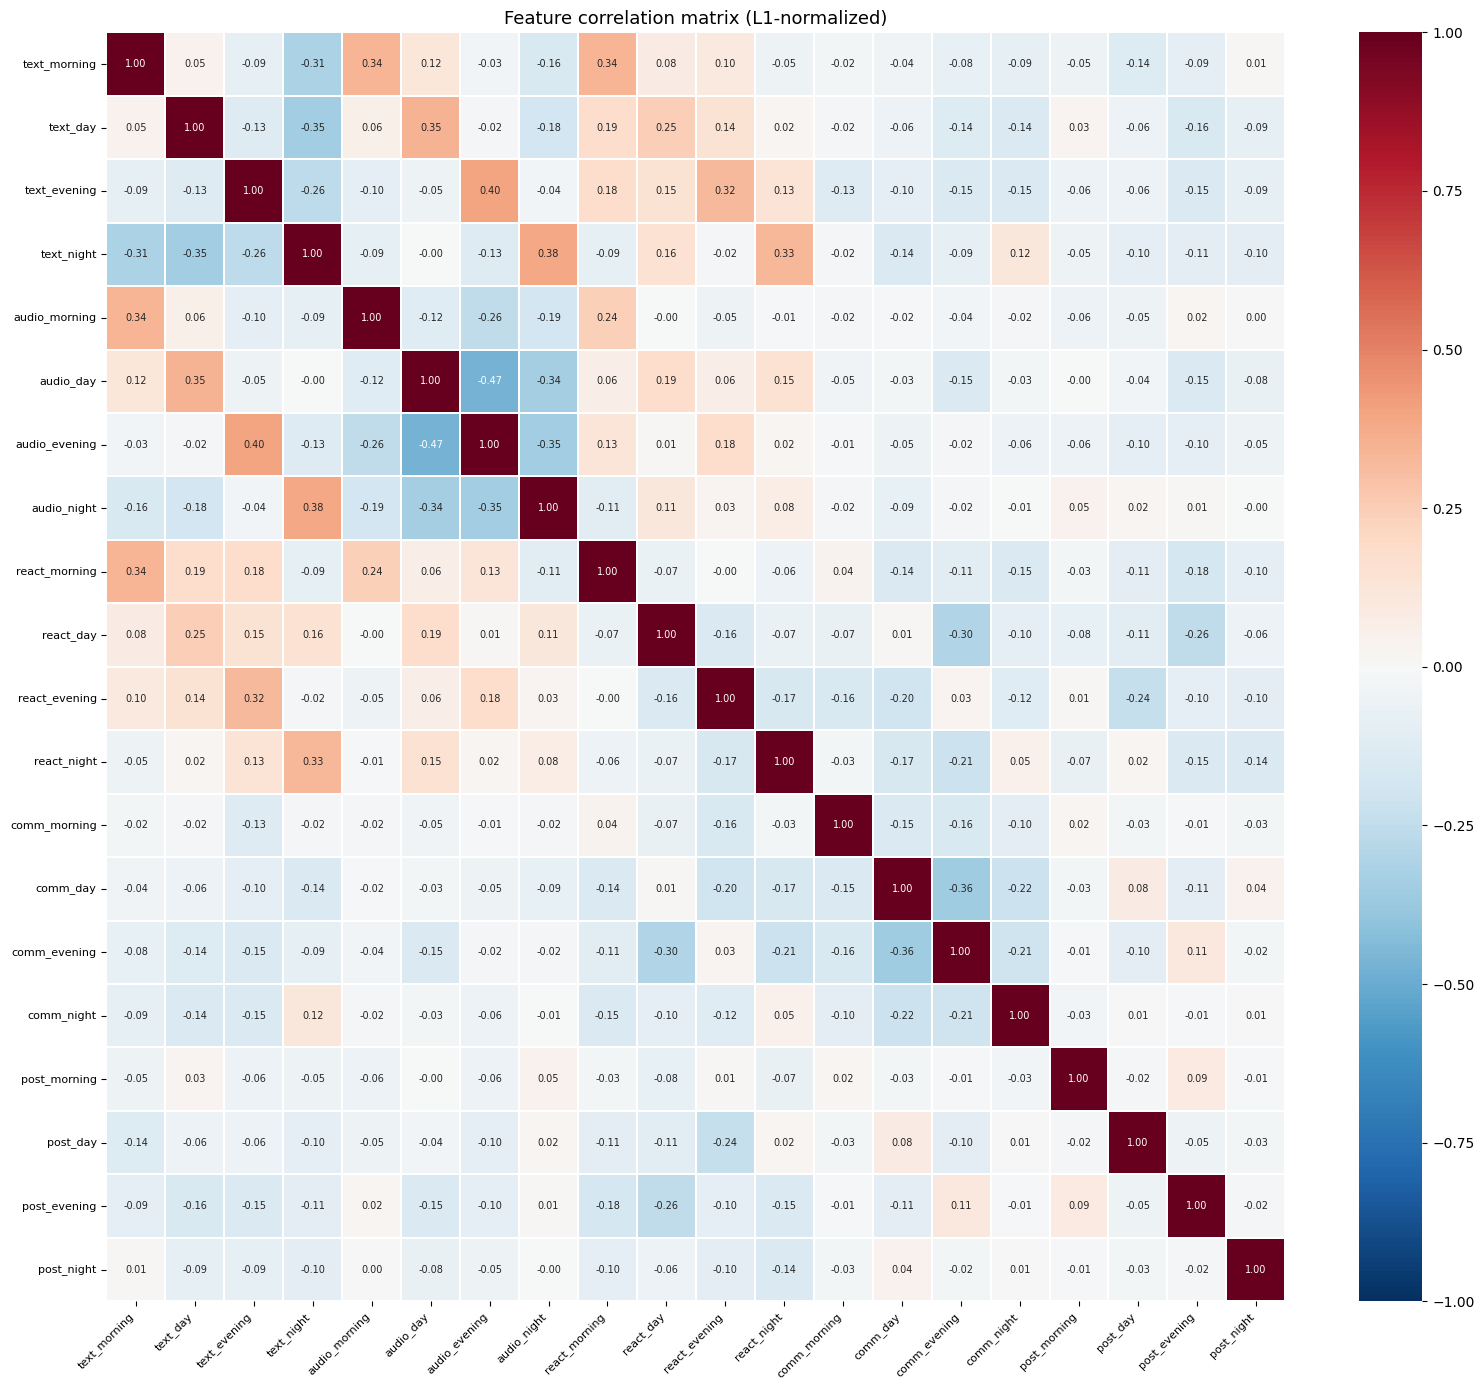

In [10]:
corr_matrix = pd.DataFrame(X_norm, columns=feat_cols).corr()

plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix,
            cmap='RdBu_r',
            center=0,
            vmin=-1, vmax=1,
            annot=True,
            fmt='.2f',
            annot_kws={'size': 7},
            linewidths=0.3)
plt.title('Feature correlation matrix (L1-normalized)', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [11]:
X_pca_2d = PCA(n_components=2).fit_transform(X_norm)

X_tsne_2d = TSNE(
    n_components=2,
    perplexity=min(30, len(X_norm) // 2),
    random_state=random_state,
    max_iter=1000
).fit_transform(X_norm)

X_umap_2d = umap.UMAP(
    metric='cosine',
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=random_state
).fit_transform(X_norm)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [12]:
def plot_clusters_and_period(labels, title):
    period = day_df['period'].values
    projections = [
        ('PCA', X_pca_2d, 'PC1', 'PC2'),
        ('t-SNE', X_tsne_2d, 'T1', 'T2'),
        ('UMAP', X_umap_2d, 'U1', 'U2'),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    for col, (proj_name, X_2d, xl, yl) in enumerate(projections):
        df_vis = pd.DataFrame(X_2d, columns=[xl, yl])
        df_vis['cluster'] = labels
        df_vis['period'] = period
        
        sns.scatterplot(data=df_vis, x=xl, y=yl,
                        hue='cluster', palette='tab10', alpha=0.8,
                        ax=axes[0, col])
        axes[0, col].set_title(f'{title} — clusters ({proj_name})')
        axes[0, col].spines['top'].set_visible(False)
        axes[0, col].spines['right'].set_visible(False)
        
        sns.scatterplot(data=df_vis, x=xl, y=yl,
                        hue='period',
                        palette={'before Feb 24': 'steelblue', 'after Feb 24': 'tomato'},
                        alpha=0.8, ax=axes[1, col])
        axes[1, col].set_title(f'{title} — before/after ({proj_name})')
        axes[1, col].spines['top'].set_visible(False)
        axes[1, col].spines['right'].set_visible(False)
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [13]:
def plot_barplot_per_cluster(labels, title):
    tmp = day_df[['period']].copy()
    tmp['cluster'] = labels
    tmp = tmp[tmp['cluster'] >= 0]
    counts = tmp.groupby(['cluster', 'period']).size().unstack(fill_value=0)
    for col in ['before Feb 24', 'after Feb 24']:
        if col not in counts.columns:
            counts[col] = 0
    fig, ax = plt.subplots(figsize=(max(6, len(counts) * 1.5), 5))
    x = np.arange(len(counts))
    ax.bar(x, counts['before Feb 24'], label='Before Feb 24', color='steelblue', alpha=0.85)
    ax.bar(x, counts['after Feb 24'],  label='After Feb 24', color='tomato', alpha=0.85,
           bottom=counts['before Feb 24'])
    for i, (pre, post) in enumerate(zip(counts['before Feb 24'], counts['after Feb 24'])):
        if pre > 3:
            ax.text(i, pre / 2, str(int(pre)), ha='center', va='center',
                    color='white', fontweight='bold', fontsize=10)
        if post > 3:
            ax.text(i, pre + post / 2, str(int(post)), ha='center', va='center',
                    color='white', fontweight='bold', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([f'Cluster {c}' for c in counts.index], fontsize=11)
    ax.set_ylabel('Number of days', fontsize=11)
    ax.set_title(f'Days per cluster: pre vs post (2022-02-24)\n{title}', fontsize=12)
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

In [14]:
def describe_clusters(labels, title):
    tmp = day_df.copy()
    tmp['cluster'] = labels
    tmp = tmp[tmp['cluster'] >= 0]
    print(f'{title} — cluster sizes:')
    print(tmp['cluster'].value_counts().sort_index())
    if -1 in labels:
        print(f'Noise points: {(np.array(labels) == -1).sum()}')

In [15]:
def cluster_profile(labels, title):
    tmp = day_df[feat_cols].copy()
    tmp['cluster'] = labels
    tmp = tmp[tmp['cluster'] >= 0]
    means = tmp.groupby('cluster').mean()
    summary = []
    for cl in sorted(means.index):
        top5 = means.loc[cl].sort_values(ascending=False).head(5)
        row = {'Cluster': f'Cluster {cl}'}
        for rank, (feat, val) in enumerate(top5.items(), 1):
            row[f'#{rank}'] = f'{feat} ({val:.3f})'
        summary.append(row)
    summary_df = pd.DataFrame(summary).set_index('Cluster')
    print(f'\n{title} — top-5 features per cluster')
    display(summary_df)

#### K-Means

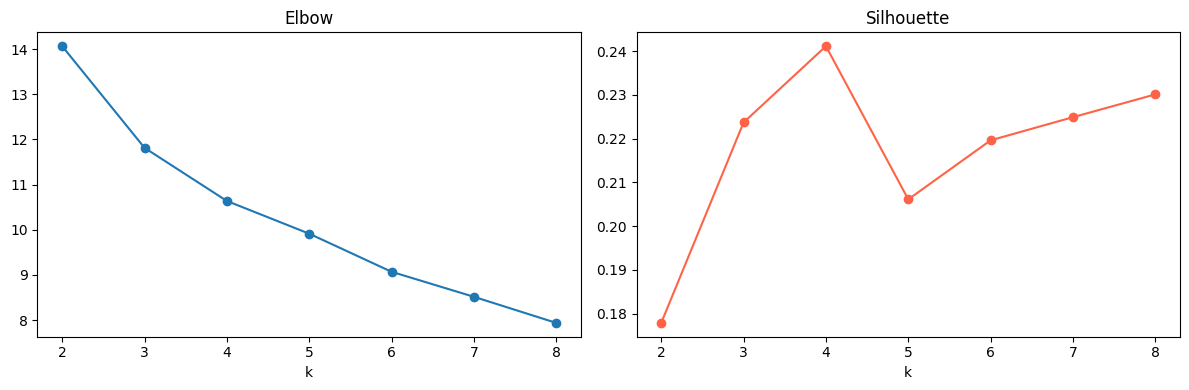

Best k: 4 (silhouette=0.2411)


In [16]:
inertia, sil = [], []
K_range = range(2, 9)

for k in K_range:
    km  = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    lbl = km.fit_predict(X_norm)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_norm, lbl))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_range, inertia, marker='o')
ax1.set_title('Elbow')
ax1.set_xlabel('k')
ax2.plot(K_range, sil, marker='o', color='tomato')
ax2.set_title('Silhouette')
ax2.set_xlabel('k')
plt.tight_layout()
plt.show()

best_k = K_range[sil.index(max(sil))]
print(f'Best k: {best_k} (silhouette={max(sil):.4f})')

Using k = 4
Silhouette: 0.2411
KMeans — cluster sizes:
cluster
0     90
1     78
2     51
3    146
Name: count, dtype: int64


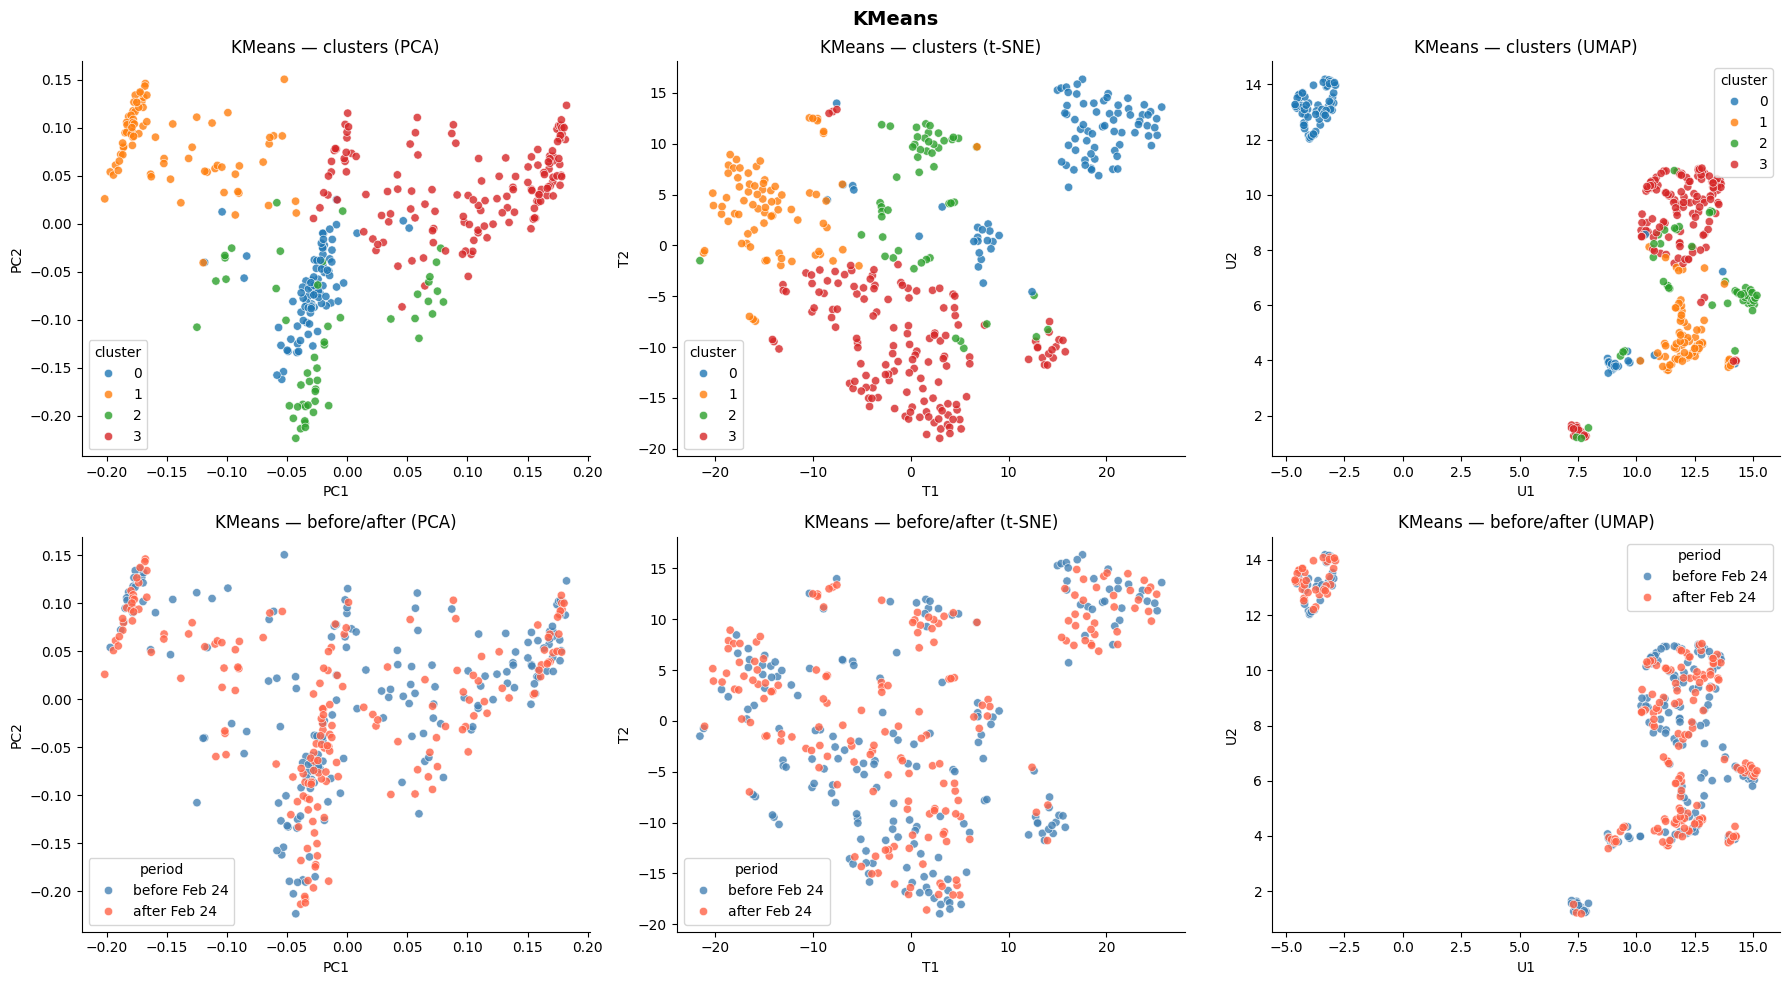

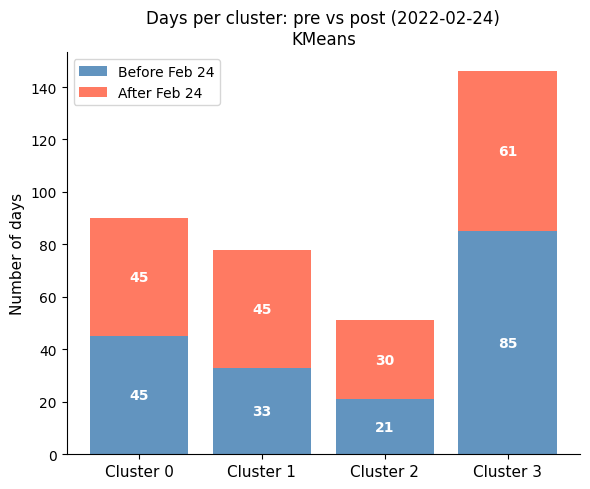


KMeans — top-5 features per cluster


,#1,#2,#3,#4,#5
Cluster,,,,,
Cluster 0,audio_day (0.360),audio_evening (0.347),text_evening (0.340),react_day (0.313),react_evening (0.310)
Cluster 1,comm_day (0.884),audio_evening (0.379),react_day (0.344),text_evening (0.335),audio_day (0.333)
Cluster 2,comm_night (0.720),audio_day (0.354),text_night (0.319),react_day (0.319),text_evening (0.313)
Cluster 3,comm_evening (0.772),audio_evening (0.355),react_evening (0.344),text_evening (0.327),audio_day (0.324)


In [17]:
manual_k = None

k_to_use = manual_k if manual_k is not None else best_k
print(f'Using k = {k_to_use}')

km = KMeans(n_clusters=k_to_use, random_state=random_state, n_init=10)
labels_km = km.fit_predict(X_norm)

print(f'Silhouette: {silhouette_score(X_norm, labels_km):.4f}')
describe_clusters(labels_km, 'KMeans')
plot_clusters_and_period(labels_km, 'KMeans')
plot_barplot_per_cluster(labels_km, 'KMeans')
cluster_profile(labels_km, 'KMeans')

#### Hierarchical clustering

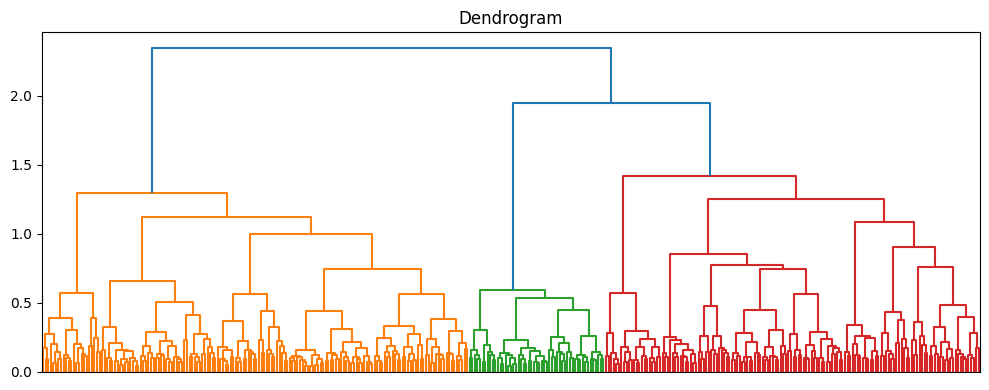

In [18]:
Z = linkage(X_norm, method='ward')
plt.figure(figsize=(10, 4))
dendrogram(Z, no_labels=True)
plt.title('Dendrogram')
plt.tight_layout()
plt.show()

Using k = 4
Silhouette: 0.1910
Hierarchical — cluster sizes:
cluster
1    166
2     53
3     22
4    124
Name: count, dtype: int64


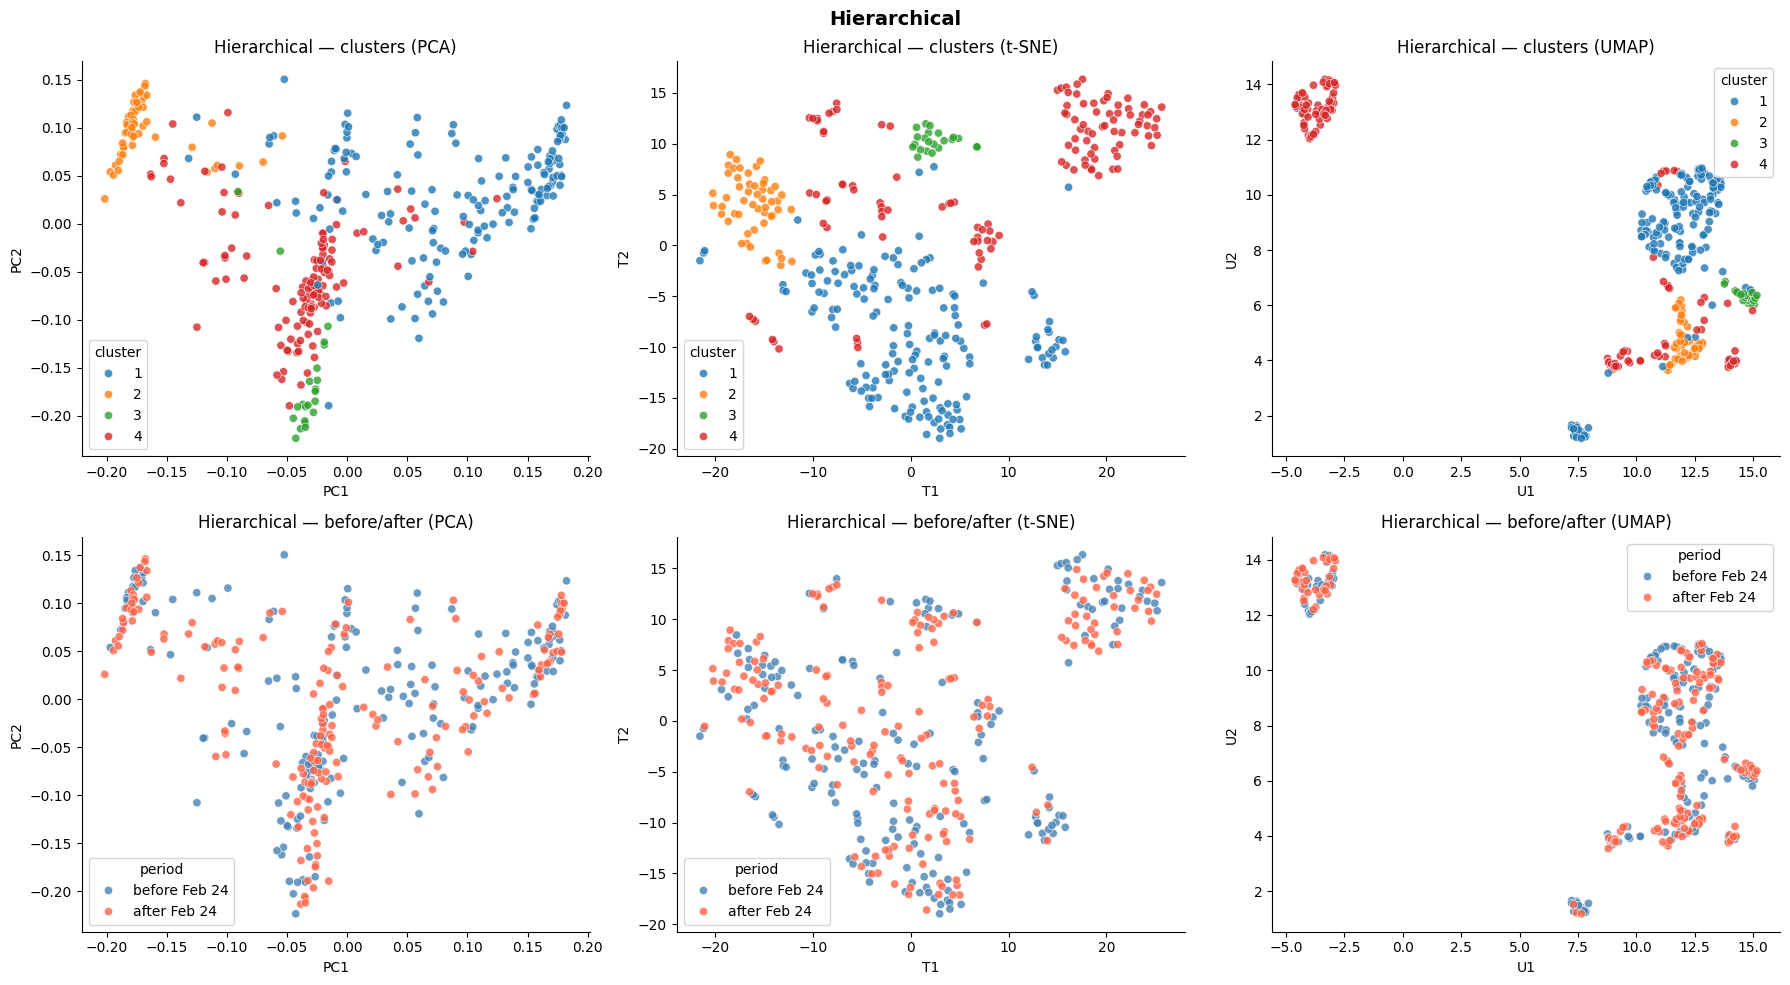

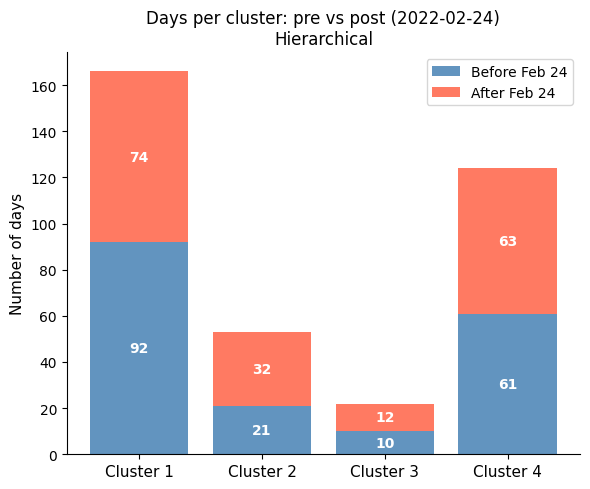


Hierarchical — top-5 features per cluster


,#1,#2,#3,#4,#5
Cluster,,,,,
Cluster 1,comm_evening (0.698),audio_evening (0.362),react_evening (0.342),text_evening (0.326),audio_day (0.323)
Cluster 2,comm_day (0.955),audio_evening (0.361),react_day (0.340),text_evening (0.327),audio_day (0.322)
Cluster 3,comm_night (0.955),audio_evening (0.414),audio_day (0.352),react_evening (0.322),text_evening (0.311)
Cluster 4,audio_day (0.366),text_evening (0.340),react_day (0.325),audio_evening (0.322),react_evening (0.300)


In [19]:
manual_k_h = None

k_to_use_h = manual_k_h if manual_k_h is not None else best_k
print(f'Using k = {k_to_use_h}')

labels_h = fcluster(Z, k_to_use_h, criterion='maxclust')

print(f'Silhouette: {silhouette_score(X_norm, labels_h):.4f}')
describe_clusters(labels_h, 'Hierarchical')
plot_clusters_and_period(labels_h, 'Hierarchical')
plot_barplot_per_cluster(labels_h, 'Hierarchical')
cluster_profile(labels_h, 'Hierarchical')

#### HDBSCAN

min_cluster_size = 15
Clusters: 2, Noise: 121
Silhouette: 0.1582
HDBSCAN — cluster sizes:
cluster
0     50
1    194
Name: count, dtype: int64
Noise points: 121


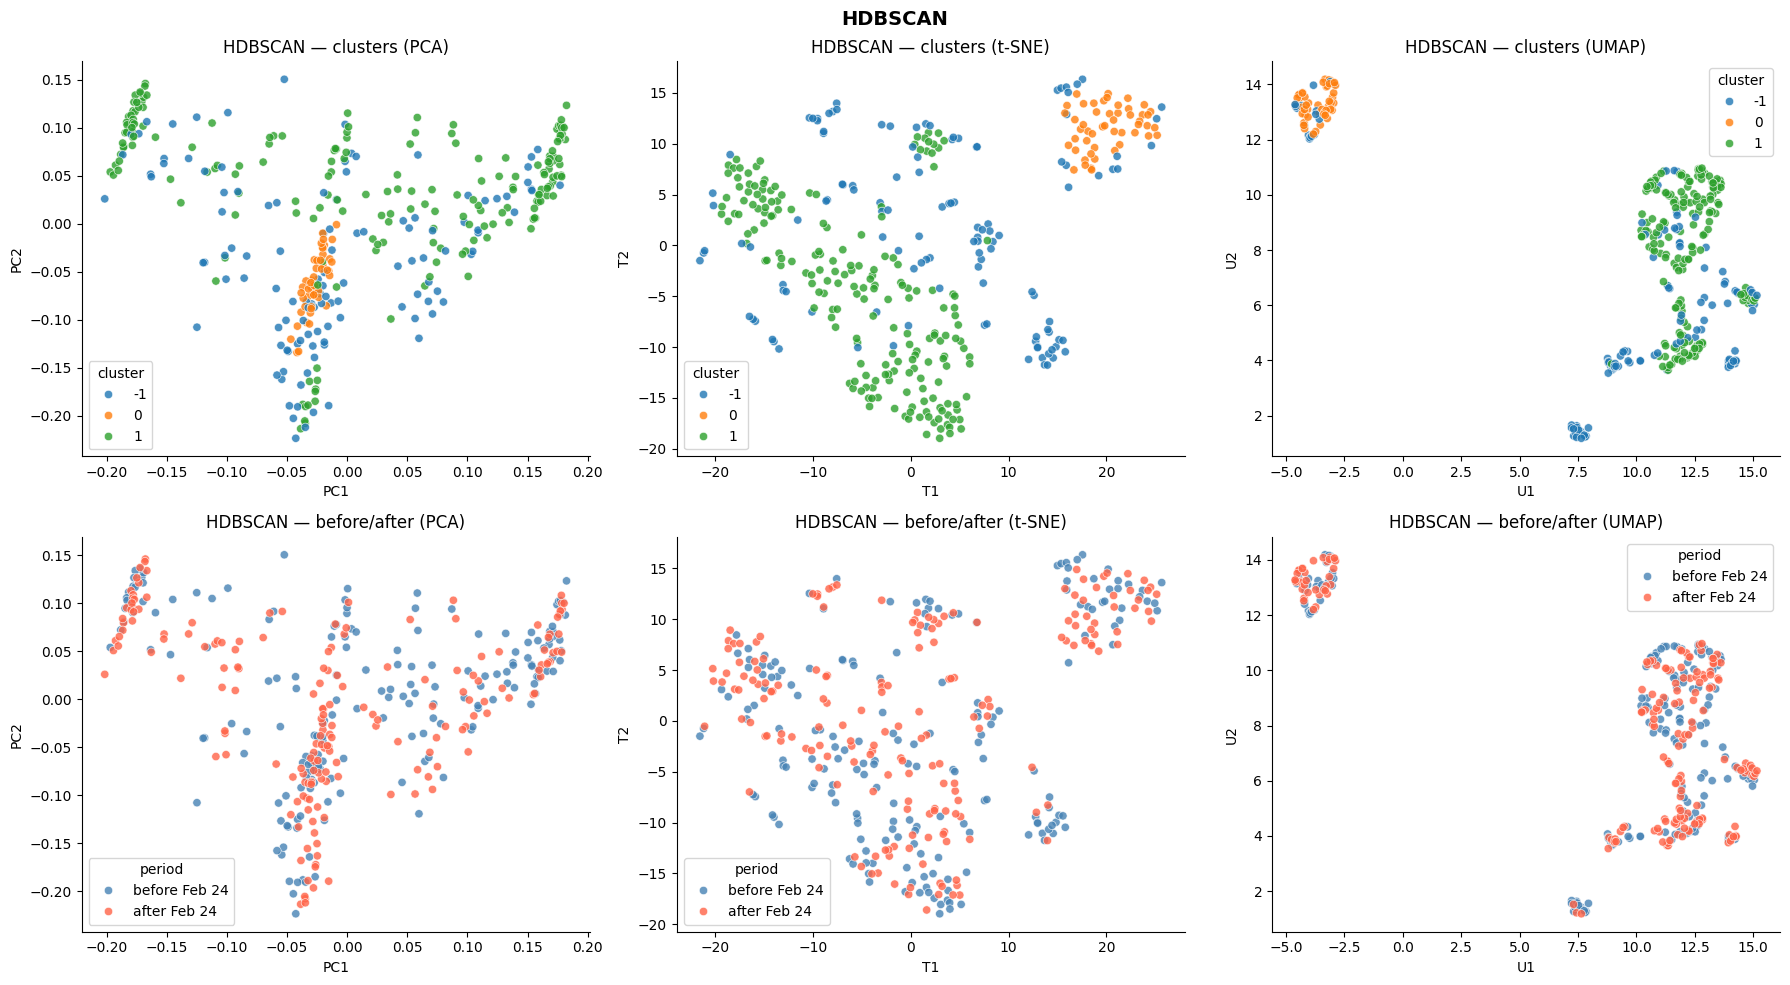

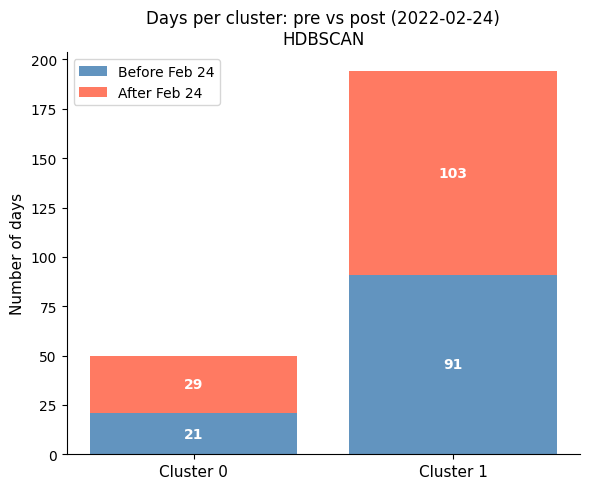


HDBSCAN — top-5 features per cluster


,#1,#2,#3,#4,#5
Cluster,,,,,
Cluster 0,audio_evening (0.387),text_evening (0.362),audio_day (0.333),react_evening (0.310),react_day (0.308)
Cluster 1,comm_evening (0.498),audio_evening (0.375),comm_day (0.353),audio_day (0.347),react_evening (0.333)


In [20]:
manual_cluster_size = None

min_size = manual_cluster_size if manual_cluster_size is not None else 15

clusterer  = hdbscan.HDBSCAN(min_cluster_size=min_size)
labels_hdb = clusterer.fit_predict(X_norm)

n_clusters = len(set(labels_hdb)) - (1 if -1 in labels_hdb else 0)
n_noise    = (labels_hdb == -1).sum()
print(f'min_cluster_size = {min_size}')
print(f'Clusters: {n_clusters}, Noise: {n_noise}')

mask = labels_hdb >= 0
if n_clusters > 1 and mask.sum() > 10:
    print(f'Silhouette: {silhouette_score(X_norm[mask], labels_hdb[mask]):.4f}')

describe_clusters(labels_hdb, 'HDBSCAN')
plot_clusters_and_period(labels_hdb, 'HDBSCAN')
plot_barplot_per_cluster(labels_hdb, 'HDBSCAN')
cluster_profile(labels_hdb, 'HDBSCAN')